In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from tqdm import tqdm

In [2]:
import os
os.chdir("../../bats_transformer/")  # Change to bats_transformer root directory

In [3]:
dataset = "july_daytime_chunked_2022"

In [4]:
data_folder = f"data/{dataset}/splits"

In [5]:
from pathlib import Path

data_path = Path(data_folder)
feather_files = sorted(data_path.glob("*.feather"))

if not feather_files:
    raise FileNotFoundError(f"No .feather files found in {data_path}")

dfs = []
for f in feather_files:
    try:
        dfs.append(pd.read_feather(f))
    except Exception as e:
        raise RuntimeError(f"Failed to read {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(feather_files)} files -> {len(df)} rows, {len(df.columns)} columns")

Loaded 11 files -> 255816 rows, 112 columns


In [6]:
import joblib
scaler = joblib.load(open(f'data/{dataset}/splits/split_scaler.pkl', 'rb'))

In [7]:
non_scaler_columns = {}

for idx, column in enumerate(df.columns):
    if column not in scaler.feature_names_in_:
        non_scaler_columns[idx] = df[column]
        df.drop(columns=[column], inplace=True)

all_features = list(scaler.feature_names_in_)
column_idxs = [] # indices of columns in predictions that are in scaler.feature_names_in_
for column in scaler.feature_names_in_:
    if column not in df.columns:
        df[column] = 0
    else:
        column_idxs.append(all_features.index(column))

df = df[scaler.feature_names_in_]

df_np = df.to_numpy()
df_np = df_np[:, :-1]

inverted_predictions = scaler.inverse_transform(df)

filtered_inverted_predictions = inverted_predictions[:, column_idxs]

original_df = pd.DataFrame(filtered_inverted_predictions, columns=[df.columns[i] for i in column_idxs])
original_df

,TimeInFile,PrecedingIntrvl,CallsPerSec,CallDuration,Fc,HiFreq,LowFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,...,meanKn-FcCurviness,Kn-FcCurvinessTrndSlp,Quality,HiFminusStartF,FcMinusEndF,RelPwr2ndTo1st,RelPwr3rdTo1st,MinAccpQuality,MaxSegLngth,Max#CallsConsidered
0,188.0,35.0,19.110309,4.340707,24.200585,36.678174,24.080314,12.597860,30.854204,66.766230,...,0.000919,0.004081,0.866370,1.829461,0.120271,0.471657,0.018071,0.6,1.0,32.0
1,188.0,35.0,19.110309,4.340707,24.200585,36.678174,24.080314,12.597860,30.854204,66.766230,...,0.000919,0.004081,0.866370,1.829461,0.120271,0.471657,0.018071,0.6,1.0,32.0
2,203.0,15.0,19.110309,3.271923,23.740920,36.009552,23.648100,12.361453,31.429211,56.173423,...,0.011335,0.011116,0.844615,3.218416,0.086265,0.524606,0.052135,0.6,1.0,32.0
3,203.0,15.0,19.110309,3.271923,23.740920,36.009552,23.648100,12.361453,31.429211,56.173423,...,0.011335,0.011116,0.844615,3.218416,0.086265,0.524606,0.052135,0.6,1.0,32.0
4,295.0,12.0,19.110309,5.314503,23.872819,36.031317,22.974408,13.056909,32.231584,50.823146,...,0.000149,0.001150,0.879189,0.000000,0.098496,0.559512,0.000000,0.6,1.0,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255811,628.0,47.0,6.027001,3.317190,28.418487,54.804683,24.811551,29.993132,34.790905,55.283956,...,0.001253,-0.001075,0.871711,0.000000,3.606937,0.633492,0.000000,0.6,1.0,32.0
255812,660.0,32.0,6.027001,3.636395,32.045388,56.958410,24.417567,32.540843,36.158262,55.931620,...,0.002124,0.003900,0.901573,0.000000,7.627821,0.535814,0.000000,0.6,1.0,32.0
255813,660.0,32.0,6.027001,3.636395,32.045388,56.958410,24.417567,32.540843,36.158262,55.931620,...,0.002124,0.003900,0.901573,0.000000,7.627821,0.535814,0.000000,0.6,1.0,32.0
255814,831.0,172.0,6.027001,4.890497,32.305078,59.050658,31.876442,27.174217,37.413006,69.096457,...,0.002369,0.003542,0.910050,0.000000,-1.256151,0.333028,0.000000,0.6,1.0,32.0


In [8]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
quantile_transformer = QuantileTransformer(output_distribution="normal")
scaled_dfs = [standard_scaled_df, robust_scaled_df, quantile_scaled_df] = [original_df.copy() for _ in range(3)]
for i, scaler in enumerate([standard_scaler, robust_scaler, quantile_transformer]):
    scaled_df = scaled_dfs[i]
    scaler.set_output(transform="pandas")
    chunk_size = 100000
    scaler.fit(original_df)
    
    scaled_df.loc[:, :] = scaler.transform(original_df.loc[:, :])

In [9]:
standard_scaled_df.columns

Index(['TimeInFile', 'PrecedingIntrvl', 'CallsPerSec', 'CallDuration', 'Fc',
       'HiFreq', 'LowFreq', 'Bndwdth', 'FreqMaxPwr', 'PrcntMaxAmpDur',
       ...
       'meanKn-FcCurviness', 'Kn-FcCurvinessTrndSlp', 'Quality',
       'HiFminusStartF', 'FcMinusEndF', 'RelPwr2ndTo1st', 'RelPwr3rdTo1st',
       'MinAccpQuality', 'MaxSegLngth', 'Max#CallsConsidered'],
      dtype='object', length=107)

In [10]:
attribute = "HiFtoKnAmp"

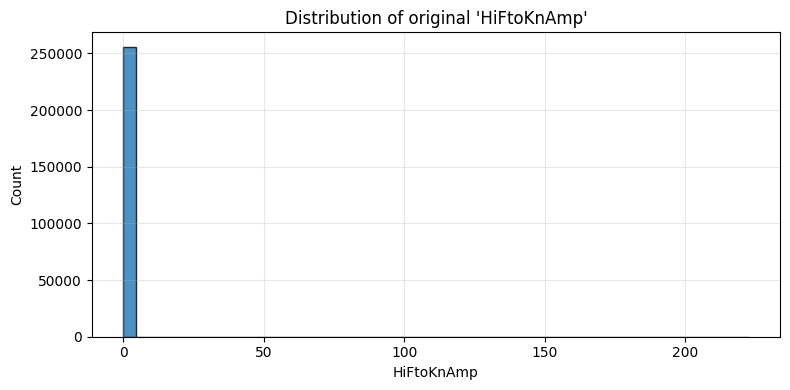

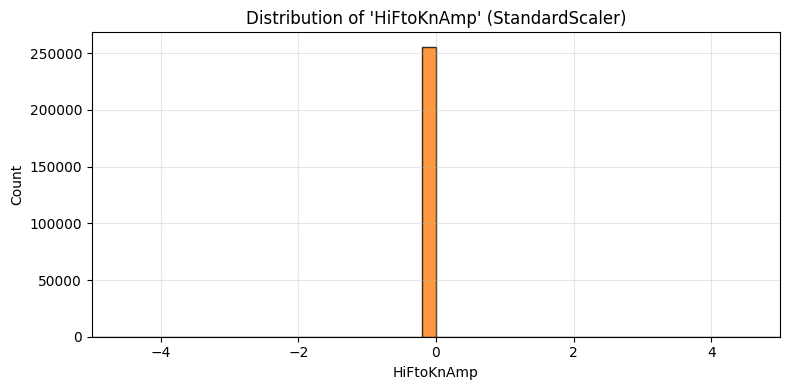

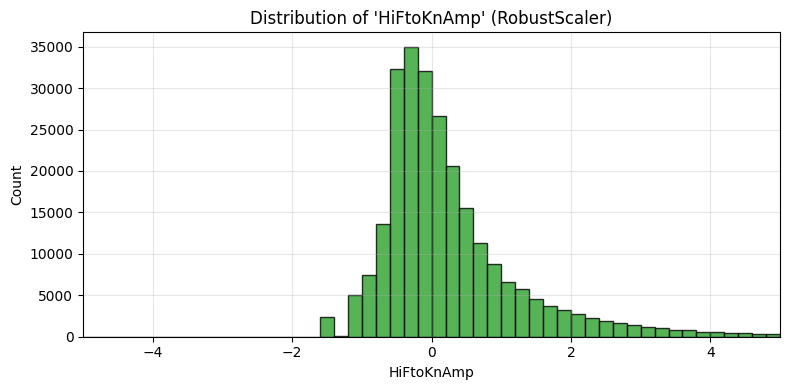

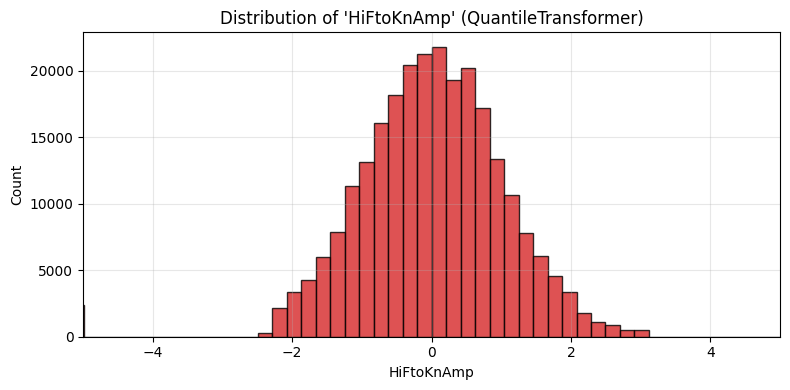

In [11]:
# import math
# plot histograms for the given attribute in two separate figures
vals = original_df[attribute].dropna()
vals_std = standard_scaled_df[attribute].dropna()
vals_robust = robust_scaled_df[attribute].dropna()
vals_quantile = quantile_scaled_df[attribute].dropna()

plt.figure(figsize=(8, 4))
plt.hist(vals_std, bins=50, color='C0', alpha=0.8, edgecolor='k')
plt.title(f"Distribution of original '{attribute}'")
plt.xlabel(attribute)
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(vals_std, bins=50, color='C1', range=(-5,5), alpha=0.8, edgecolor='k')
plt.title(f"Distribution of '{attribute}' (StandardScaler)")
plt.xlabel(attribute)
plt.xlim(-5, 5)
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(vals_robust, bins=50, color='C2', range=(-5,5), alpha=0.8, edgecolor='k')
plt.title(f"Distribution of '{attribute}' (RobustScaler)")
plt.xlabel(attribute)
plt.xlim(-5, 5)
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(vals_quantile, bins=50, color='C3', alpha=0.8, edgecolor='k')
plt.title(f"Distribution of '{attribute}' (QuantileTransformer)")
plt.xlabel(attribute)
plt.xlim(-5, 5)
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()